**Goal:** build an artificial neuron from scratch in a few lines of NumPy, see it reproduce
simple logic gates, then run head-first into the **XOR wall** -- the problem a single linear
neuron cannot solve. You will watch a `Perceptron` score pure chance on XOR, then hand-wire a
two-layer network that solves it perfectly, and finally prove that the *nonlinear activation*
-- not the extra weights -- is what makes depth work. No training and no PyTorch yet: every
weight here is set by hand, so the focus stays on *what* a network computes. Pairs with the
concept note [From Perceptrons to Neural Networks](l14_concept_perceptron_neural_networks.qmd).

> **Previously:** L13 -- Boosting (Unit IV; Exam I covers Units I-IV)  |  **Next:** L15 -- Multilayer Perceptrons (we finally train one, in PyTorch)

> This page is the read-only view. To run the lab, open the notebook
> (`l14_lab_perceptron_neural_networks.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

Our "dataset" is the smallest one imaginable: the four corners of the unit square, labelled by
a logic gate. **AND**, **OR**, and **XOR** each take two binary inputs and return one bit. AND
and OR are *linearly separable* -- you can split the 1s from the 0s with a single straight line
-- but **XOR** is the famous exception that broke the first wave of neural-network research. We
also borrow **iris-setosa** (a real, linearly separable classification problem) to show that a
single neuron is not broken in general -- it is XOR's geometry that defeats it.

Everything is definitional or seeded, so your numbers will match this page exactly.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, seeds, defines our neuron toolkit, and builds the truth tables.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships numpy, scikit-learn and matplotlib, so this is effectively a no-op there.
%pip install -q numpy scikit-learn matplotlib
# local, in a terminal (not in the notebook):  uv add numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, TOOLKIT, DATA (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

np.random.seed(0)  # determinism habit (no RNG is actually used below)

def neuron(x, w, b, phi):
    """One artificial neuron: weighted sum w.x + b, then activation phi."""
    return phi(w @ x + b)

# The activation functions from the concept note.
def step(z):     return int(z >= 0)          # the perceptron's hard threshold
def sigmoid(z):  return 1.0 / (1.0 + np.exp(-z))
def relu(z):     return np.maximum(0.0, z)   # the modern default
def identity(z): return z                    # "no activation" -- used to kill the nonlinearity

# The four corners of the unit square: inputs shared by every logic gate.
X_logic = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# XOR targets (1 only when the two inputs differ):
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

## Step 1: A Neuron in Five Lines

An artificial neuron is just a weighted sum followed by an activation. With the **step**
activation and hand-picked weights, one neuron reproduces **AND** (`w = [1, 1]`, `b = -1.5`:
fires only when both inputs are on) and **OR** (`b = -0.5`: fires when either is on):

In [3]:
w_and, b_and = np.array([1.0, 1.0]), -1.5
w_or,  b_or  = np.array([1.0, 1.0]), -0.5

print("x1 x2 | AND OR")
for x in X_logic:
    a = neuron(x, w_and, b_and, step)
    o = neuron(x, w_or,  b_or,  step)
    print(f" {x[0]}  {x[1]} |  {a}   {o}")

x1 x2 | AND OR
 0  0 |  0   0
 0  1 |  0   1
 1  0 |  0   1
 1  1 |  1   1


~~~text
x1 x2 | AND OR
 0  0 |  0   0
 0  1 |  0   1
 1  0 |  0   1
 1  1 |  1   1
~~~

Same neuron, same step activation -- only the bias differs. Shifting `b` slides the decision
threshold: `-1.5` demands two "on" inputs (AND), `-0.5` demands just one (OR). A single neuron
is a tiny, tunable linear decision rule.

## Step 2: Activation Functions

The activation `phi` is the neuron's only nonlinearity. Plot the four from the concept note and
read off their shapes -- the flat **step** versus the smooth, trainable curves:

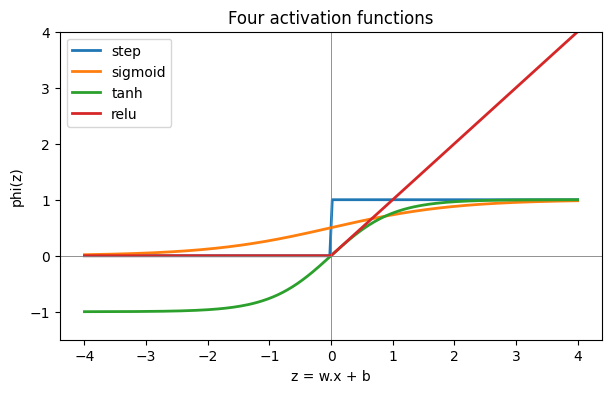

z=-2:  step=0  sigmoid=0.119  tanh=-0.964  relu=0.0
z=+0:  step=1  sigmoid=0.500  tanh=+0.000  relu=0.0
z=+2:  step=1  sigmoid=0.881  tanh=+0.964  relu=2.0


In [4]:
z = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, [step(v) for v in z], label="step",    linewidth=2)
ax.plot(z, sigmoid(z),           label="sigmoid", linewidth=2)
ax.plot(z, np.tanh(z),           label="tanh",    linewidth=2)
ax.plot(z, relu(z),              label="relu",    linewidth=2)
ax.axhline(0, color="gray", linewidth=0.6); ax.axvline(0, color="gray", linewidth=0.6)
ax.set_xlabel("z = w.x + b"); ax.set_ylabel("phi(z)"); ax.set_ylim(-1.5, 4)
ax.legend(); ax.set_title("Four activation functions")
plt.show()

# the same four, sampled at three points:
for v in (-2.0, 0.0, 2.0):
    print(f"z={v:+.0f}:  step={step(v)}  sigmoid={sigmoid(v):.3f}  tanh={np.tanh(v):+.3f}  relu={relu(v):.1f}")

~~~text
z=-2:  step=0  sigmoid=0.119  tanh=-0.964  relu=0.0
z=+0:  step=1  sigmoid=0.500  tanh=+0.000  relu=0.0
z=+2:  step=1  sigmoid=0.881  tanh=+0.964  relu=2.0
~~~

The **step** jumps from 0 to 1 with a slope of zero everywhere else -- nudging a weight changes
nothing until the output suddenly flips, which is why gradient descent (L03) cannot train it.
**Sigmoid** and **tanh** are smooth S-curves with a usable slope; **ReLU** is flat below zero
and a straight line above, cheap and the default hidden activation in modern networks.

## Step 3: The XOR Wall

A single neuron draws a single straight line, so it can only solve problems a line can split.
Fit a `Perceptron` to XOR and to the linearly separable iris-setosa problem, and compare:

In [5]:
from sklearn.datasets import load_iris

clf_xor = Perceptron(random_state=42).fit(X_xor, y_xor)
print(f"single neuron on XOR:    accuracy {accuracy_score(y_xor, clf_xor.predict(X_xor)):.3f}")

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = (iris.target == 0).astype(int).values   # setosa vs rest (linearly separable)
clf_iris = Perceptron(random_state=42).fit(X_iris, y_iris)
print(f"single neuron on setosa: accuracy {accuracy_score(y_iris, clf_iris.predict(X_iris)):.3f}")

single neuron on XOR:    accuracy 0.500


single neuron on setosa: accuracy 1.000


~~~text
single neuron on XOR:    accuracy 0.500
single neuron on setosa: accuracy 1.000
~~~

The same model is perfect (**1.000**) on setosa and no better than a coin flip (**0.500**) on
XOR. The neuron is not broken -- XOR is simply not linearly separable. Plot the four XOR points
and the line the perceptron settled on, and you can see it: no straight line puts the two 1s
together while keeping the two 0s out.

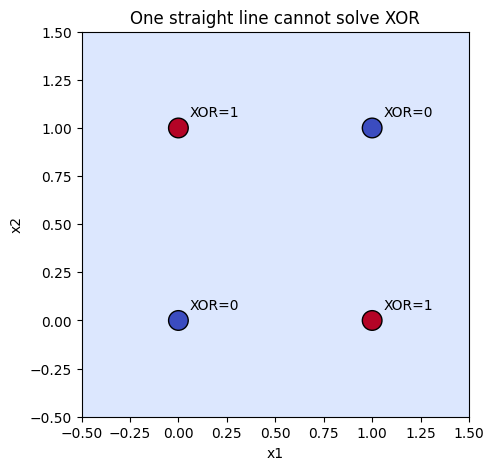

In [6]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf_xor.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", edgecolors="k", s=200)
for (x1, x2), t in zip(X_xor, y_xor):
    ax.annotate(f"XOR={t}", (x1, x2), textcoords="offset points", xytext=(8, 8))
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title("One straight line cannot solve XOR")
plt.show()

## Step 4: Break the Wall with a Hidden Layer -- completion problem

Add a **hidden layer** of two neurons -- one computing **OR**, one computing **NAND** (not-and)
-- and feed both into an output neuron that computes **AND**. Since
`XOR = (x1 OR x2) AND NOT(x1 AND x2)`, this two-layer network reproduces XOR exactly. The hidden
layer is given; **complete the output neuron's weights and bias** so it computes AND of the two
hidden outputs (reuse the `w = [1, 1]`, `b = -1.5` you found in Step 1):

In [7]:
# Uncomment and complete the output neuron (it must compute AND of the two hidden values):
# def hidden(x):
#     h1 = neuron(x, np.array([1.0, 1.0]), -0.5, step)    # OR
#     h2 = neuron(x, np.array([-1.0, -1.0]), 1.5, step)   # NAND
#     return np.array([h1, h2])
#
# def xor_net(x):
#     h = hidden(x)
#     return neuron(h, np.array([____, ____]), ____, step)   # <-- AND of (OR, NAND)
#
# preds = [xor_net(x) for x in X_xor]
# print("x1 x2 | hidden(OR,NAND) | pred (target)")
# for x, t in zip(X_xor, y_xor):
#     h = hidden(x)
#     print(f" {x[0]}  {x[1]}  |     ({int(h[0])}, {int(h[1])})      |   {xor_net(x)}  ({t})")
# print(f"network accuracy on XOR: {accuracy_score(y_xor, preds):.3f}")

<details><summary>Expected Output</summary>

~~~text
x1 x2 | hidden(OR,NAND) | pred (target)
 0  0  |     (0, 1)      |   0  (0)
 0  1  |     (1, 1)      |   1  (1)
 1  0  |     (1, 1)      |   1  (1)
 1  1  |     (1, 0)      |   0  (0)
network accuracy on XOR: 1.000
~~~

The output neuron uses `w = [1, 1]`, `b = -1.5` -- AND, exactly as in Step 1. The trick is that
it never sees the raw inputs: it sees what the hidden layer **computed** (OR and NAND), and on
those two derived features the 1s and 0s *are* linearly separable. Stacking turned an
impossible problem into an easy one -- **1.000**.
</details>

## Your Turn

### Exercise 1 -- Kill the nonlinearity

Is it the hidden layer's extra weights that solve XOR, or the *nonlinear* step activation?
Test it: rebuild the same two-layer network but swap the hidden activation for `identity` (a
linear "do nothing"), keep the step on the output, and report the accuracy. What happens, and
why?

**Hint:** copy the Step 4 solution, change only the hidden neurons' activation from `step` to `identity`, then predict on `X_xor`.

In [8]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
predictions: [0, 0, 0, 0]
linear hidden layer on XOR: accuracy 0.500
~~~

With a linear hidden layer the network collapses to a single linear classifier. A linear hidden
layer hands the output neuron only a linear combination of the inputs -- `W2 (W1 x) = (W2 W1) x`
-- so the output is just one linear-then-step rule on the original `x`, exactly the single neuron
that already failed XOR. With these particular weights the two linear hidden units cancel the
input dependence entirely, leaving a constant pre-activation that the output step maps to 0 for
all four points (hence the all-zeros prediction and 0.500). The **nonlinear** hidden activation,
not the extra weights, is the ingredient that breaks the XOR wall.
</details>

### Exercise 2 -- Rebuild it with ReLU

The step function solved XOR but cannot be trained. Show that the *modern* default activation
works too: build a hidden layer of two **ReLU** neurons -- `relu(x1 + x2)` and
`relu(x1 + x2 - 1)` -- with an output neuron using weights `[1, -2]` and bias `0` (a linear
output). Confirm it still solves XOR.

**Hint:** `hidden = [relu(x1+x2), relu(x1+x2-1)]`; output `= 1*h1 + (-2)*h2`; wrap the output in `int(...)`.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
predictions: [0, 1, 1, 0]
ReLU hidden layer on XOR: accuracy 1.000
~~~

ReLU reaches the same place by a different route: `relu(x1+x2) - 2*relu(x1+x2-1)` equals 0, 1, 0
as the input sum goes 0, 1, 2 -- exactly XOR. The depth-plus-nonlinearity recipe is not tied to
the historical step function; it works with the ReLU units that real networks use, which L15
will *train* instead of hand-wiring.
</details>

## Summary

- An **artificial neuron** is a weighted sum `w.x + b` followed by an activation `phi(z)`; with
  the step activation and hand-set biases it reproduced AND and OR.
- The **activation functions** differ in shape: the step has zero gradient (untrainable), while
  sigmoid, tanh, and **ReLU** (the modern default) are smooth enough for gradient descent.
- A single linear neuron hit the **XOR wall** -- 0.500, pure chance -- yet scored 1.000 on the
  linearly separable setosa problem, so the failure is XOR's geometry, not the neuron.
- A **hidden layer** (OR and NAND feeding an AND) solved XOR exactly (1.000); replacing its
  nonlinear activation with the identity collapsed it back to 0.500, proving the nonlinearity
  is what works. ReLU solved it too.
- Next (L15): stop hand-wiring weights -- meet **PyTorch** and *train* a multilayer perceptron.